<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/Deep-Learning-Projects/blob/main/Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [16]:
df = load_iris()
X, y = df.data, df.target
class_names = df.target_names

In [17]:
print("Features are: ", df.feature_names)
print("Prediction classes:", df.target_names)
print("Data set size:", X.shape[0])

print("\nExample sample: ", X[0], "->", y[0], ":", class_names[0])

Features are:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Prediction classes: ['setosa' 'versicolor' 'virginica']
Data set size: 150

Example sample:  [5.1 3.5 1.4 0.2] -> 0 : setosa


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("X_train: ", X_train_scaled.shape, "80% of 150")
print("X_test : ", X_test_scaled.shape, "  20% of 150")

X_train:  (120, 4) 80% of 150
X_test :  (30, 4)   20% of 150


In [21]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(16, activation = 'relu'))
model.add(Dense(3, activation = 'softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer= 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs = 50, batch_size = 32, validation_split=0.1)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.7685 - loss: 0.9904 - val_accuracy: 0.6667 - val_loss: 0.9675
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7593 - loss: 0.9045 - val_accuracy: 0.7500 - val_loss: 0.9208
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7870 - loss: 0.8337 - val_accuracy: 0.7500 - val_loss: 0.8773
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7963 - loss: 0.7727 - val_accuracy: 0.7500 - val_loss: 0.8347
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8056 - loss: 0.7168 - val_accuracy: 0.7500 - val_loss: 0.7930
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8056 - loss: 0.6604 - val_accuracy: 0.7500 - val_loss: 0.7535
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8056 - loss: 0.6075 - val_accuracy: 0.7500 - val_loss: 0.7128
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8148 - loss: 0.5574 - val_accuracy: 0.7500 - val_loss: 0.6738


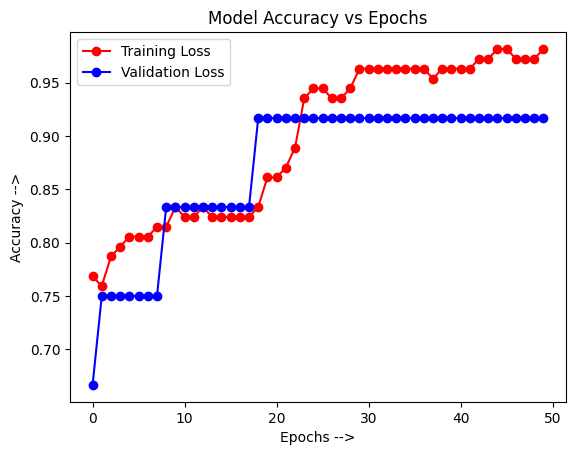

In [23]:
plt.plot(history.history['accuracy'],color='r',marker='o', label='Training Loss')
plt.plot(history.history['val_accuracy'],color='b',marker='o', label='Validation Loss')
plt.title('Model Accuracy vs Epochs')
plt.xlabel('Epochs -->')
plt.ylabel('Accuracy -->')
plt.legend()
plt.show()

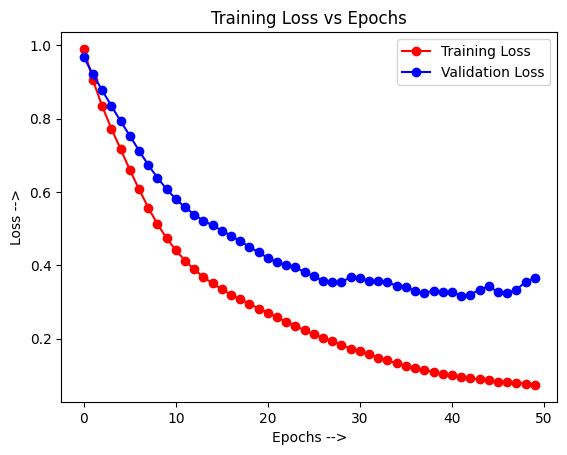

In [24]:
plt.plot(history.history['loss'],color='r',marker='o', label='Training Loss')
plt.plot(history.history['val_loss'],color='b',marker='o', label='Validation Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs -->')
plt.ylabel('Loss -->')
plt.legend()
plt.show()

In [25]:
X_test_scaled[0:1]

array([[ 0.35451684, -0.58505976,  0.55777524,  0.02224751]])

In [26]:
logits = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


In [27]:
preds = class_names[np.argmax(logits, axis = 1)]

In [28]:
for i in range(len(preds)):
  print(f"Actual:{class_names[y_test[i]]}, Prediction:{preds[i]}")

print("\nMatch counts: ", {np.sum(np.equal(preds, class_names[y_test]))})

Actual:versicolor, Prediction:versicolor
Actual:setosa, Prediction:setosa
Actual:virginica, Prediction:virginica
Actual:versicolor, Prediction:versicolor
Actual:versicolor, Prediction:versicolor
Actual:setosa, Prediction:setosa
Actual:versicolor, Prediction:versicolor
Actual:virginica, Prediction:virginica
Actual:versicolor, Prediction:versicolor
Actual:versicolor, Prediction:versicolor
Actual:virginica, Prediction:virginica
Actual:setosa, Prediction:setosa
Actual:setosa, Prediction:setosa
Actual:setosa, Prediction:setosa
Actual:setosa, Prediction:setosa
Actual:versicolor, Prediction:versicolor
Actual:virginica, Prediction:virginica
Actual:versicolor, Prediction:versicolor
Actual:versicolor, Prediction:versicolor
Actual:virginica, Prediction:virginica
Actual:setosa, Prediction:setosa
Actual:virginica, Prediction:virginica
Actual:setosa, Prediction:setosa
Actual:virginica, Prediction:virginica
Actual:virginica, Prediction:virginica
Actual:virginica, Prediction:virginica
Actual:virginica